# Notebook 3 - Actor-Critic NO-RERANK (LONG-TERM, full catalog) - self-contained

Khac NB2: Actor cham **TOAN BO 3706 phim** (BERT chi lam encoder, KHONG loc top-N). q=state+delta, init delta=0 -> khoi dau = ranking full cua BERT. Reward=graded NDCG theo rating. Eval DCG so BERT. Chart actor/critic/val. wandb.

In [1]:
import os, sys, json, math, random
import numpy as np, pandas as pd, torch
import torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import matplotlib.pyplot as plt
HERE = os.path.abspath("bert_ac_longterm") if os.path.isdir("bert_ac_longterm") else os.getcwd()
ROOT = os.path.dirname(HERE); sys.path.insert(0, ROOT)
from Bert4Rec_model import BERT4Rec, BERT4RecDataset, gather_indexes, train_one_epoch  # CHI import file model goc
import wandb
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 200
RATING_FILE = os.path.join(ROOT, "Data_Movielens_1m", "ml-1m", "ratings.dat")
ENV_FILE = os.path.join(ROOT, ".env")
def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
set_seed(42)
def load_env_key(p, key="wandb_api_key"):
    if not os.path.exists(p): return None
    for line in open(p, encoding="utf-8"):
        if "=" in line:
            k, v = line.split("=", 1)
            if k.strip() == key: return v.strip()
    return None
print("Device:", DEVICE)

Device: cuda


## Helpers (inline)

In [2]:
def load_and_split(rating_file, test_frac=0.2, min_len=5, max_len=MAX_LEN):
    cols = ["UserID","MovieID","Rating","Timestamp"]
    df = pd.read_csv(rating_file, sep="::", engine="python", names=cols)
    df = df.sort_values(["UserID","Timestamp"]).reset_index(drop=True)
    raw = sorted(df["MovieID"].unique()); m2i = {m:i+1 for i,m in enumerate(raw)}; n_items = len(raw)
    df["enc"] = df["MovieID"].map(m2i); df["pair"] = list(zip(df["enc"], df["Rating"].astype(float)))
    seqs = df.groupby("UserID")["pair"].apply(list).to_dict()
    users=[]; bseqs=[]; ni=nt=nr=0
    for _, seq in seqs.items():
        if len(seq) < min_len: continue
        n=len(seq); ts=max(1,round(test_frac*n)); rem=seq[:-ts]; test=seq[-ts:]
        if len(rem) < 2: continue
        rs=max(1,round(test_frac*len(rem))); rh=rem[:-rs]; rr=rem[-rs:]
        if len(rh) < 1: rh=rem[:1]; rr=rem[1:] or rem[-1:]
        ri=[m for m,r in rem][-max_len:]
        users.append({"hist_items":ri,"test_rel":{int(m):float(r) for m,r in test},
                      "rl_hist_items":[m for m,r in rh][-max_len:],"rl_rel":{int(m):float(r) for m,r in rr}})
        bseqs.append(ri); ni+=n; nt+=len(test); nr+=len(rem)
    stats={"n_users":len(users),"n_items":n_items,"n_interactions":int(ni),"n_train_remaining":int(nr),
           "n_test":int(nt),"avg_seq_len":round(ni/max(1,len(users)),2),
           "avg_test_len":round(nt/max(1,len(users)),2),"test_frac":test_frac,"max_len":max_len}
    return users, bseqs, n_items, m2i, stats

@torch.no_grad()
def encode_states(bert, hist_list, max_len=MAX_LEN, bs=256):
    bert.eval(); outs=[]
    for i in range(0,len(hist_list),bs):
        chunk=hist_list[i:i+bs]; b=len(chunk)
        item_seq=torch.zeros((b,max_len),dtype=torch.long,device=DEVICE)
        slen=torch.zeros((b,),dtype=torch.long,device=DEVICE)
        for j,s in enumerate(chunk):
            L=min(len(s),max_len); slen[j]=max(L,1)
            if L>0: item_seq[j,:L]=torch.tensor(s[-L:],dtype=torch.long,device=DEVICE)
        so=bert.forward(bert.reconstruct_test_data(item_seq,slen)); outs.append(gather_indexes(so,slen-1))
    return torch.cat(outs,0)

def dcg_at_k(r,rel,k):
    s=0.0
    for i,it in enumerate(r[:k]):
        g=rel.get(int(it),0.0)
        if g>0: s+=(2.0**g-1.0)/math.log2(i+2)
    return s
def ndcg_at_k(r,rel,k):
    ideal=sorted(rel.values(),reverse=True)
    idcg=sum((2.0**g-1.0)/math.log2(i+2) for i,g in enumerate(ideal[:k]))
    return dcg_at_k(r,rel,k)/idcg if idcg>0 else 0.0
def recall_at_k(r,rel,k):
    return (sum(1 for it in r[:k] if int(it) in rel)/len(rel)) if rel else 0.0
def agg(ranks,rels,ks=(5,10,20)):
    m={}
    for k in ks:
        m[f"DCG@{k}"]=float(np.mean([dcg_at_k(r,rl,k) for r,rl in zip(ranks,rels)]))
        m[f"NDCG@{k}"]=float(np.mean([ndcg_at_k(r,rl,k) for r,rl in zip(ranks,rels)]))
        m[f"Recall@{k}"]=float(np.mean([recall_at_k(r,rl,k) for r,rl in zip(ranks,rels)]))
    return m

@torch.no_grad()
def rank_bert(bert, users, target="test", subset=None, K=20):
    hk="hist_items" if target=="test" else "rl_hist_items"; rk="test_rel" if target=="test" else "rl_rel"
    idx=list(range(len(users))) if subset is None else subset
    item_emb=bert.item_embedding.weight[:bert.n_items]; bias=bert.output_bias
    S=encode_states(bert,[users[i][hk] for i in idx]); ranks=[]
    for i in range(0,S.shape[0],256):
        sc=S[i:i+256]@item_emb.T+bias; sc[:,0]=-1e9
        ranks+=torch.topk(sc,K,1).indices.cpu().numpy().tolist()
    return ranks, [users[i][rk] for i in idx]
print("[+] helpers ready")

[+] helpers ready


## 1. Time-split + nap BERT (NB1) dong bang

In [3]:
users, bert_seqs, n_real, movie2id, stats = load_and_split(RATING_FILE)
n_model = n_real + 1
json.dump(stats, open(os.path.join(HERE,"data_stats.json"),"w"), ensure_ascii=False, indent=2)
print(json.dumps(stats, ensure_ascii=False, indent=2))
bert=BERT4Rec(n_items=n_model, max_seq_length=MAX_LEN, hidden_size=64, n_layers=2, n_heads=2,
              hidden_dropout_prob=0.2, attn_dropout_prob=0.2, loss_type="CE").to(DEVICE)
bert.load_state_dict(torch.load(os.path.join(HERE,"bert4rec.pth"), map_location=DEVICE)); bert.eval()
for p in bert.parameters(): p.requires_grad=False
print("BERT loaded & frozen")

{
  "n_users": 6040,
  "n_items": 3706,
  "n_interactions": 1000209,
  "n_train_remaining": 800193,
  "n_test": 200016,
  "avg_seq_len": 165.6,
  "avg_test_len": 33.12,
  "test_frac": 0.2,
  "max_len": 200
}
BERT loaded & frozen


C:\Users\TanPhat\AppData\Local\Temp\ipykernel_34588\2848081563.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  bert.load_state_dict(torch.load(os.path.join(HERE,"bert4re

## 2. Actor-Critic NO-RERANK (cham toan kho)

In [4]:
# ====== ACTOR-CRITIC NO-RERANK (toan kho) - REINFORCE + value baseline ======
# Khac NB2: KHONG lay top-N cua BERT. Actor cham TAT CA 3706 phim.
# BERT chi lam ENCODER (state). Actor: q = state + delta(state) [init delta=0 -> = BERT full ranking].
class ActorFull(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(dim,256), nn.ReLU(), nn.Linear(256,dim))
        nn.init.zeros_(self.net[-1].weight); nn.init.zeros_(self.net[-1].bias)
    def forward(self, state):
        return state + self.net(state)          # q (init = state -> diem = BERT)

class ValueNet(nn.Module):
    def __init__(self, dim):
        super().__init__(); self.net=nn.Sequential(nn.Linear(dim,128),nn.ReLU(),nn.Linear(128,1))
    def forward(self, state): return self.net(state).squeeze(-1)

ITEM_EMB = bert.item_embedding.weight[:bert.n_items].detach()   # [n_items, H]
BIAS = bert.output_bias.detach()

def scores_all(actor, st):
    q = actor(st)
    sc = q @ ITEM_EMB.T + BIAS
    sc[:, 0] = -1e9                              # cam pad
    return sc

def gains_from_rel(chosen_ids, rel_dicts):
    B,K = chosen_ids.shape; g=np.zeros((B,K),dtype=np.float32); cid=chosen_ids.cpu().numpy()
    for b in range(B):
        rel=rel_dicts[b]
        for j in range(K):
            r=rel.get(int(cid[b,j]),0.0)
            if r>0: g[b,j]=2.0**r-1.0
    return torch.tensor(g, device=chosen_ids.device)

def idcg_from_rel(rel_dicts, K, device):
    out=np.zeros(len(rel_dicts),dtype=np.float32); disc=1.0/np.log2(np.arange(K)+2)
    for b,rel in enumerate(rel_dicts):
        ideal=sorted((2.0**r-1.0 for r in rel.values()), reverse=True)[:K]
        out[b]=float(np.sum(np.array(ideal)*disc[:len(ideal)]))
    return torch.tensor(out, device=device).clamp(min=1e-8)

@torch.no_grad()
def rank_acf(bert, actor, users, target="test", subset=None, K=20):
    hk="hist_items" if target=="test" else "rl_hist_items"; rk="test_rel" if target=="test" else "rl_rel"
    idx=list(range(len(users))) if subset is None else subset
    S=encode_states(bert,[users[i][hk] for i in idx]); ranks=[]
    for i in range(0,S.shape[0],256):
        sc=scores_all(actor, S[i:i+256])
        ranks+=torch.topk(sc,K,1).indices.cpu().numpy().tolist()
    return ranks, [users[i][rk] for i in idx]

def val_dcg10(bert, actor, users, subset):
    rk,rl=rank_acf(bert,actor,users,target="rl",subset=subset,K=10)
    return float(np.mean([dcg_at_k(r,x,10) for r,x in zip(rk,rl)]))

def train_acf(bert, users, epochs=30, bs=256, K=10, lr=1e-4, patience=8, run=None):
    dim=bert.hidden_size
    actor=ActorFull(dim).to(DEVICE); critic=ValueNet(dim).to(DEVICE)
    aopt=optim.Adam(actor.parameters(),lr); copt=optim.Adam(critic.parameters(),lr)
    disc=(1.0/torch.log2(torch.arange(K,device=DEVICE).float()+2)).unsqueeze(0)
    rl_rel=[u["rl_rel"] for u in users]
    S=encode_states(bert,[u["rl_hist_items"] for u in users]).cpu(); N=S.shape[0]
    val_sub=list(range(0,N,max(1,N//2000)))[:2000]
    hist={"actor":[],"critic":[],"val_dcg10":[],"train_reward":[]}
    base=val_dcg10(bert,actor,users,val_sub); print(f"[ACF] VAL DCG@10 init(=BERT)={base:.4f}")
    best,best_sd,noimp=base,{k:v.detach().clone() for k,v in actor.state_dict().items()},0
    for ep in range(epochs):
        actor.train(); critic.train(); perm=np.random.permutation(N); ea=ec=er=0.0; nb=0
        for i in range(0,N,bs):
            bidx=perm[i:i+bs]; st=S[bidx].to(DEVICE); rels=[rl_rel[j] for j in bidx]
            sc=scores_all(actor, st)                       # [b, n_items] TOAN KHO
            avail=torch.ones_like(sc,dtype=torch.bool); avail[:,0]=False
            logp=torch.zeros(sc.shape[0],device=DEVICE); chosen=torch.zeros(sc.shape[0],K,dtype=torch.long,device=DEVICE)
            for t in range(K):
                m=torch.distributions.Categorical(F.softmax(sc.masked_fill(~avail,-1e9),-1))
                a=m.sample(); logp=logp+m.log_prob(a); chosen[:,t]=a
                avail.scatter_(1,a.unsqueeze(1),False)
            g=gains_from_rel(chosen, rels)                 # [b,K]
            dcg=(g*disc).sum(1); idcg=idcg_from_rel(rels,K,DEVICE); reward=dcg/idcg
            V=critic(st); adv=(reward-V).detach()
            aloss=-(adv*logp).mean(); closs=F.mse_loss(V,reward)
            aopt.zero_grad(); aloss.backward(); aopt.step()
            copt.zero_grad(); closs.backward(); copt.step()
            ea+=aloss.item(); ec+=closs.item(); er+=reward.mean().item(); nb+=1
        va,vc,vr=ea/nb,ec/nb,er/nb; vd=val_dcg10(bert,actor,users,val_sub)
        for k_,v_ in [("actor",va),("critic",vc),("train_reward",vr),("val_dcg10",vd)]: hist[k_].append(v_)
        print(f"[ACF] ep {ep+1:02d}/{epochs}  actor={va:.4f} critic={vc:.4f} reward={vr:.4f}  VAL DCG@10={vd:.4f}" + ("  <- best" if vd>best+1e-6 else f" (best {best:.4f},{noimp+1}/{patience})"))
        if run:
            try: run.log({"acf/actor_loss":va,"acf/critic_loss":vc,"acf/train_reward":vr,"acf/val_dcg10":vd,"acf/epoch":ep+1})
            except Exception: pass
        if vd>best+1e-6: best=vd; best_sd={k:v.detach().clone() for k,v in actor.state_dict().items()}; noimp=0
        else:
            noimp+=1
            if noimp>=patience: print(f"[ACF] EARLY STOP ep {ep+1}, best={best:.4f} (BERT init={base:.4f})"); break
    actor.load_state_dict(best_sd); return actor,hist,base
print("[+] Actor-Critic NO-RERANK defined")

[+] Actor-Critic NO-RERANK defined


## 3. Train (+ wandb)

In [5]:
key=load_env_key(ENV_FILE); run=None
try:
    if key: wandb.login(key=key)
    run=wandb.init(project="bert4rec-ac-longterm", name="actor-critic-norerank", reinit=True)
except Exception as e: print("wandb off:", e)
actor, hist, base = train_acf(bert, users, epochs=30, bs=256, K=10, patience=8, run=run)
torch.save(actor.state_dict(), os.path.join(HERE,"actor_norerank.pth"))
if run:
    try: run.finish()
    except Exception: pass
print("saved actor_norerank.pth | BERT-init VAL DCG@10 =", round(base,4))

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.


wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\TanPhat\_netrc


wandb: Currently logged in as: lamgiang (lamgiang-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


...

wandb: uploading history steps 0-7, summary, console lines 1-9


wandb: 
wandb: Run history:
wandb:   acf/actor_loss ▁▁▄▇▇▆█▆
wandb:  acf/critic_loss █▁▁▄▅▅▇█
wandb:        acf/epoch ▁▂▃▄▅▆▇█
wandb: acf/train_reward ▁▁▂▄▅▆▇█
wandb:    acf/val_dcg10 ███▇▅▅▅▁
wandb: 
wandb: Run summary:
wandb:   acf/actor_loss -0.03414
wandb:  acf/critic_loss 0.00385
wandb:        acf/epoch 8
wandb: acf/train_reward 0.02707
wandb:    acf/val_dcg10 4.03833
wandb: 


wandb:  View run actor-critic-norerank at: https://wandb.ai/lamgiang-fpt-university/bert4rec-ac-longterm/runs/aaew9q63
wandb:  View project at: https://wandb.ai/lamgiang-fpt-university/bert4rec-ac-longterm
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: .\wandb\run-20260619_215403-aaew9q63\logs


saved actor_norerank.pth | BERT-init VAL DCG@10 = 4.0847


## 4. Chart: Actor / Critic loss / VAL DCG@10

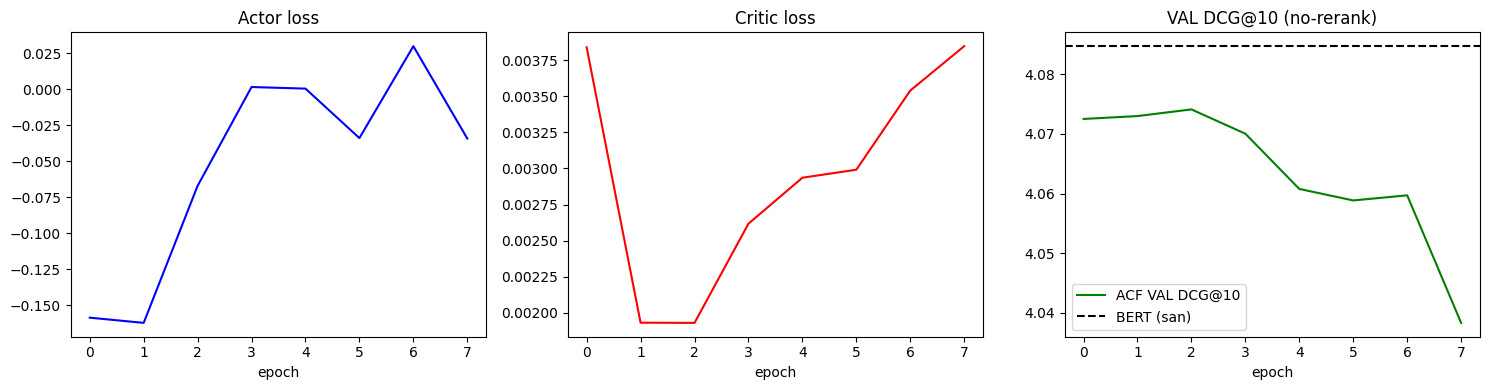

In [6]:
fig,ax=plt.subplots(1,3,figsize=(15,4))
ax[0].plot(hist["actor"],color="blue"); ax[0].set_title("Actor loss"); ax[0].set_xlabel("epoch")
ax[1].plot(hist["critic"],color="red"); ax[1].set_title("Critic loss"); ax[1].set_xlabel("epoch")
ax[2].plot(hist["val_dcg10"],color="green",label="ACF VAL DCG@10"); ax[2].axhline(base,ls="--",color="black",label="BERT (san)")
ax[2].set_title("VAL DCG@10 (no-rerank)"); ax[2].set_xlabel("epoch"); ax[2].legend()
plt.tight_layout(); plt.show()

## 5. Eval DCG: BERT vs BERT+AC(no-rerank)

In [7]:
rb,rl=rank_bert(bert,users,target="test",K=20); res_bert=agg(rb,rl)
ra,rl2=rank_acf(bert,actor,users,target="test",K=20); res_acf=agg(ra,rl2)
results={"data_stats":stats,"BERT (short-term)":res_bert,"BERT + Actor-Critic (no-rerank, full catalog)":res_acf}
json.dump(results, open(os.path.join(HERE,"results_norerank.json"),"w"), ensure_ascii=False, indent=2)
COLS=["DCG@5","DCG@10","DCG@20","NDCG@10","Recall@10"]
print(f"{'Model':<40}"+"".join(f"{c:>11}" for c in COLS)); print("-"*(40+11*len(COLS)))
for name,m in [("BERT (short-term)",res_bert),("BERT+AC (no-rerank, full catalog)",res_acf)]:
    print(f"{name:<40}"+"".join(f"{m[c]:>11.4f}" for c in COLS))

Model                                         DCG@5     DCG@10     DCG@20    NDCG@10  Recall@10
-----------------------------------------------------------------------------------------------
BERT (short-term)                            2.7359     3.9998     6.3018     0.0367     0.0220
BERT+AC (no-rerank, full catalog)            2.7359     3.9998     6.3018     0.0367     0.0220
